In [36]:
import numpy as np
from utils.data_utils import TitanicDataHelper
import warnings
from utils.evaluation_utils import EvaluationHelper
from utils.tree_utils import TreeHelper
warnings.filterwarnings("ignore")

## Data Visualization

In [37]:
x_train, x_test, y_train, y_test = TitanicDataHelper.load_dataset(normalize=False)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((712, 10), (179, 10), (712,), (179,))

In [38]:
x_train.head()

,Pclass,Age,SibSp,Parch,Fare,UncommonTitle,YoungTitle,Sex_male,Embarked_Q,Embarked_S
709,3,28.0,1,1,15.2458,0,1,1,0,0
439,2,31.0,0,0,10.5000,0,0,1,0,1
840,3,20.0,0,0,7.9250,0,0,1,0,1
720,2,6.0,0,1,33.0000,0,1,0,0,1
39,3,14.0,1,0,11.2417,0,1,0,0,0


In [39]:
y_train.head()

709    1
439    0
840    0
720    1
39     1
Name: Survived, dtype: int64

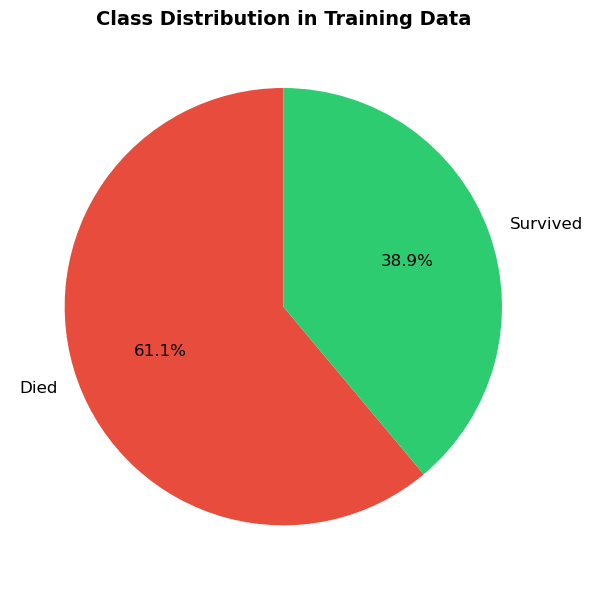

Died: 435 (61.1%)
Survived: 277 (38.9%)


In [40]:
TitanicDataHelper.plot_outcome_distribution(x_train, y_train)

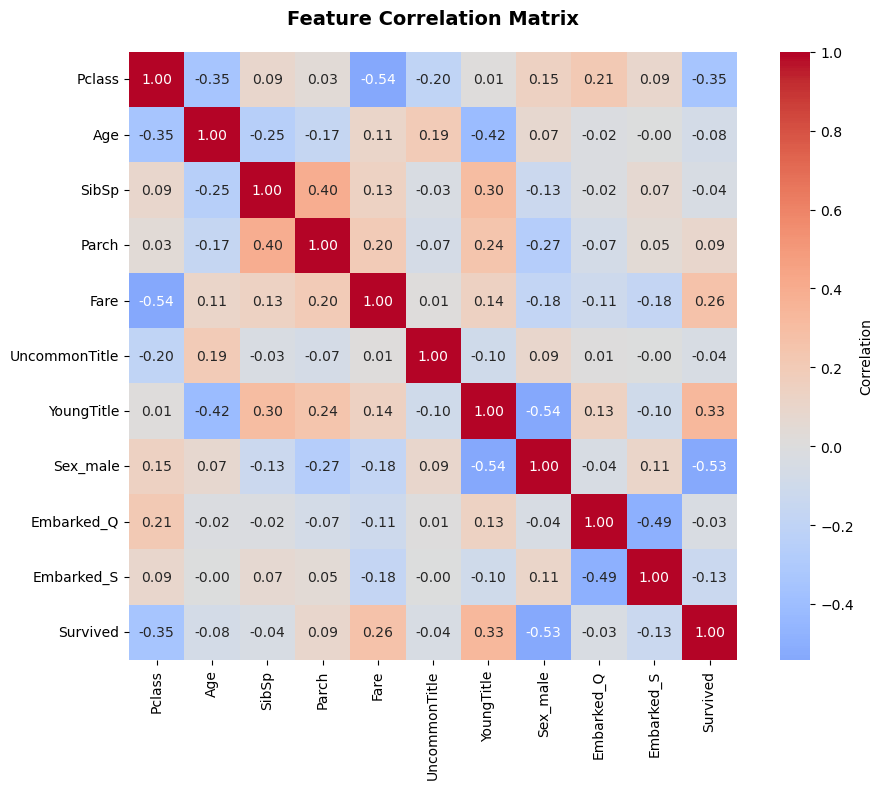

In [41]:
TitanicDataHelper.plot_correlation(x_train, y_train)

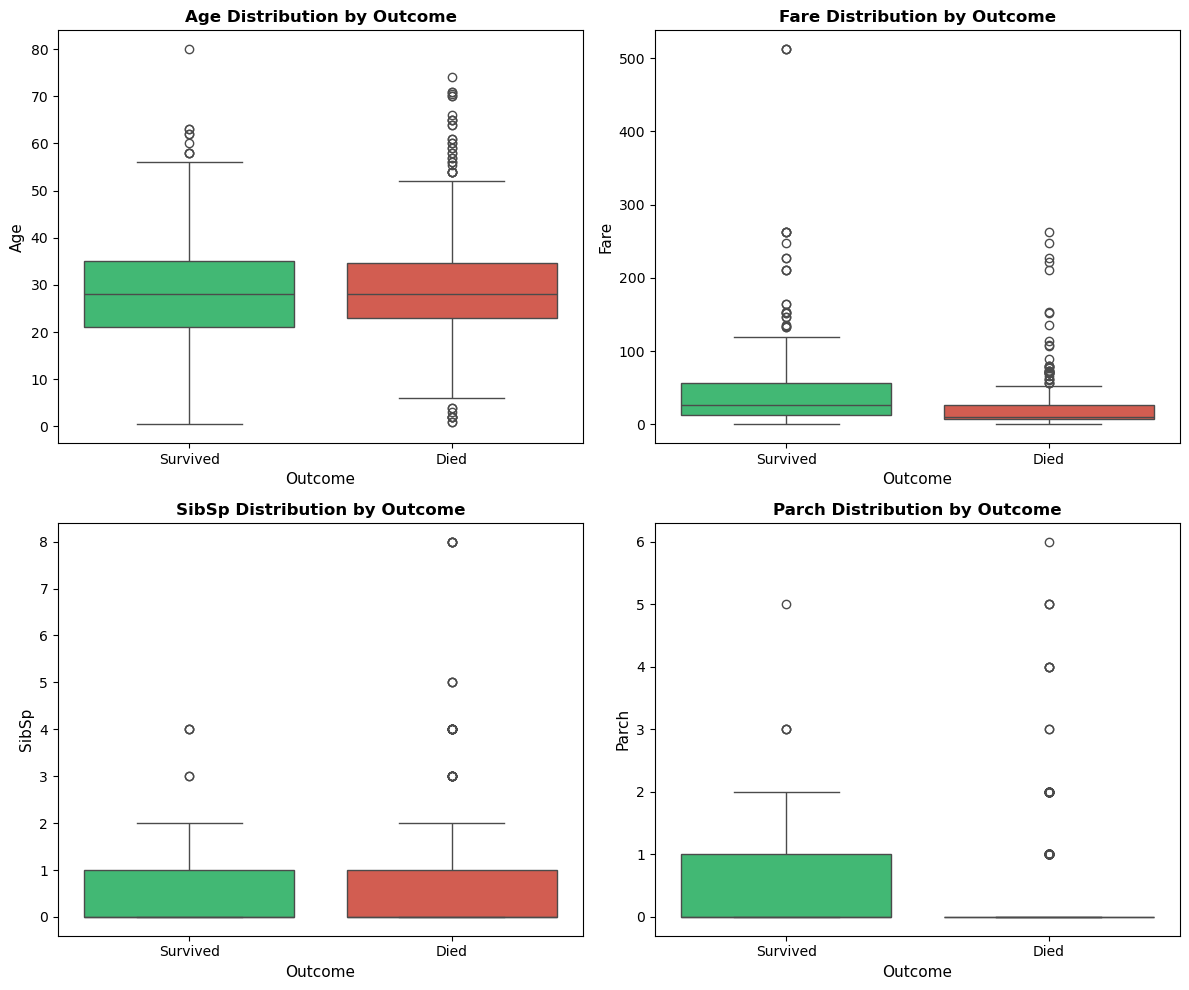

In [42]:
TitanicDataHelper.plot_boxplots(x_train, y_train)

## Model Training

In [43]:
x_survived = x_train[y_train == 1]
x_died = x_train[y_train == 0]

In [44]:
class Node:
    def __init__(self, feature=None, threshold=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.value = value
        self.left = None
        self.right = None

    def append_left(self, node):
        self.left = node
    
    def append_right(self, node):
        self.right = node
    
    def split_left_right(self, data):
        left_data = data[data[self.feature] <= self.threshold]
        right_data = data[data[self.feature] > self.threshold]
        return left_data, right_data

In [45]:
def compute_impurity(data):
    if len(data) == 0:
        return 0
    
    survived_prob = data["Survived"].mean()
    died_prob = 1 - survived_prob
    
    prob_sum = survived_prob ** 2 + died_prob ** 2
    return 1 - prob_sum

In [46]:
def find_best_split(data, thresholds_size=20):
    prior_impurity = compute_impurity(data)
    best_split = {"gain": 0, "feature": None, "threshold": None}
    
    for feature in data.drop(columns=["Survived"]).columns:
        thresholds = np.linspace(start=data[feature].min(), stop=data[feature].max(), num=thresholds_size)
        
        for threshold in thresholds:
            left_data = data[data[feature] <= threshold]
            right_data = data[data[feature] > threshold]
            
            if len(left_data) == 0 or len(right_data) == 0:
                continue
            
            left_impurity = compute_impurity(left_data)
            right_impurity = compute_impurity(right_data)
            
            weighted_left_impurity = (len(left_data) / len(data)) * left_impurity
            weighted_right_impurity = (len(right_data) / len(data)) * right_impurity
            
            weighted_impurity = weighted_left_impurity + weighted_right_impurity
            gain = prior_impurity - weighted_impurity
            
            split = {"gain": gain, "feature": feature, "threshold": threshold}
            
            if gain > best_split["gain"]:
                best_split = split
            
    return best_split

In [47]:
def build_tree(data, max_depth=10, depth=0):
    if depth >= max_depth or len(data) <= 1:
        if len(data) == 0:
            prob = 0
        else:
            prob = data["Survived"].mean()
        return Node(value=prob)
    
    best_split = find_best_split(data)
    if best_split["gain"] <= 0 or best_split["feature"] is None:
        prob = data["Survived"].mean()
        return Node(value=prob)
    
    node = Node(best_split["feature"], best_split["threshold"])
    left_data, right_data = node.split_left_right(data)
    
    node.left = build_tree(left_data, max_depth, depth + 1)
    node.right = build_tree(right_data, max_depth, depth + 1)
    
    return node

In [48]:
x_train_labelled = x_train.copy()
x_train_labelled["Survived"] = y_train

tree = build_tree(x_train_labelled, max_depth=4)

In [49]:
def predict(node, x):
    if node.value is not None:
        return node.value >= 0.5, node.value
    if x[node.feature] <= node.threshold:
        return predict(node.left, x)
    else:
        return predict(node.right, x)

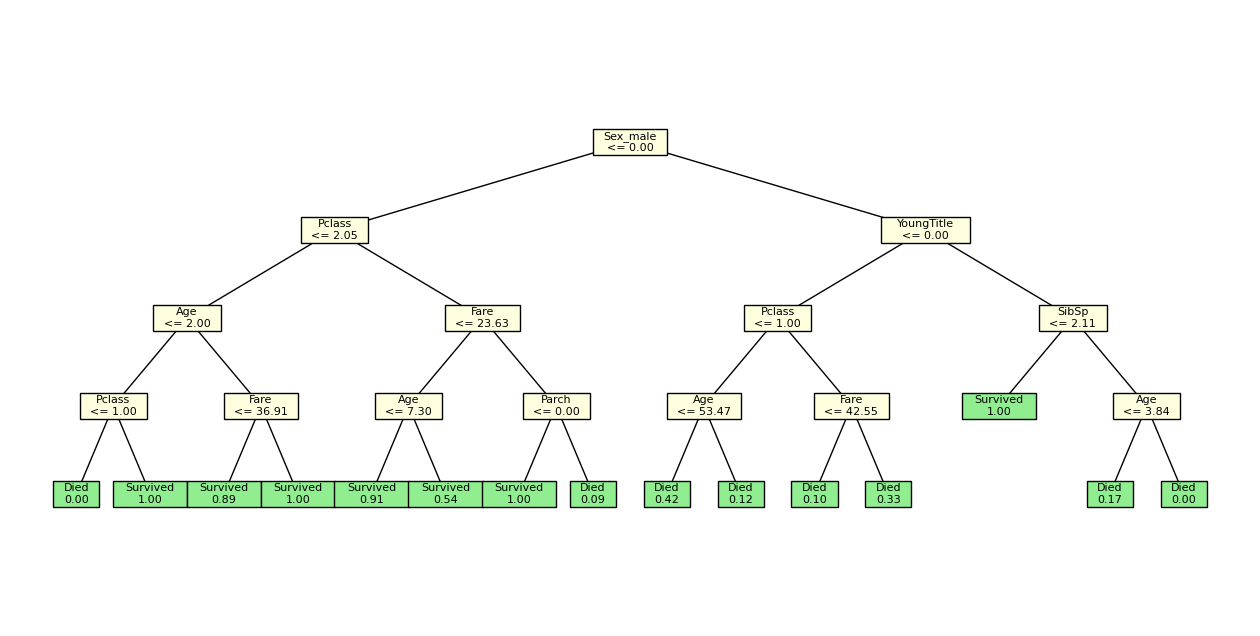

In [50]:
TreeHelper.plot_decision_tree(tree, ["Died", "Survived"], (16, 8))

## Model Evaluation

In [51]:
predictions = []
probabilities = []

for idx, x in x_test.iterrows():
    prediction, prob = predict(tree, x)
    predictions.append(prediction)
    probabilities.append(prob)

predictions = np.array(predictions)
probabilities = np.array(probabilities)

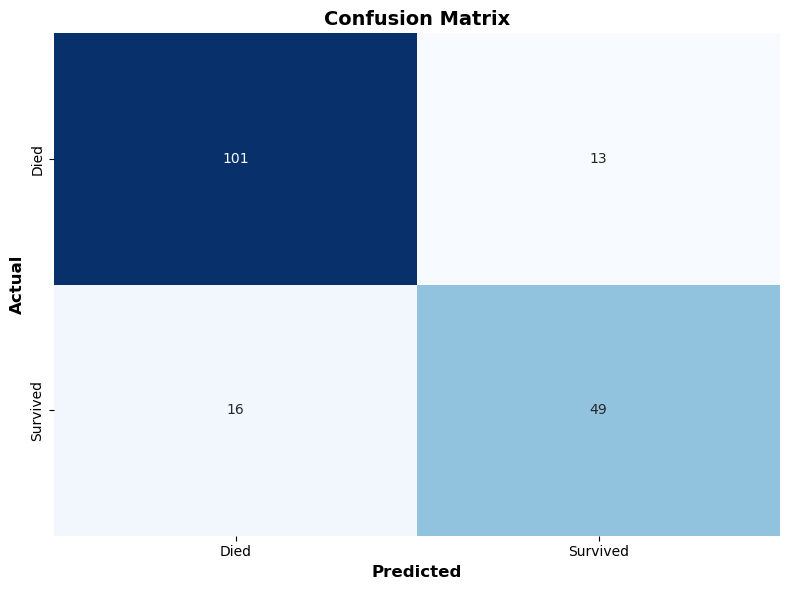

True Negatives: 101
False Positives: 13
False Negatives: 16
True Positives: 49

Sensitivity (Recall): 0.7538
Specificity: 0.8860
Precision: 0.7903
Accuracy: 0.8380
F1 Score: 0.7717


In [52]:
EvaluationHelper.plot_confusion_matrix(y_test, predictions, class_names=["Died", "Survived"])

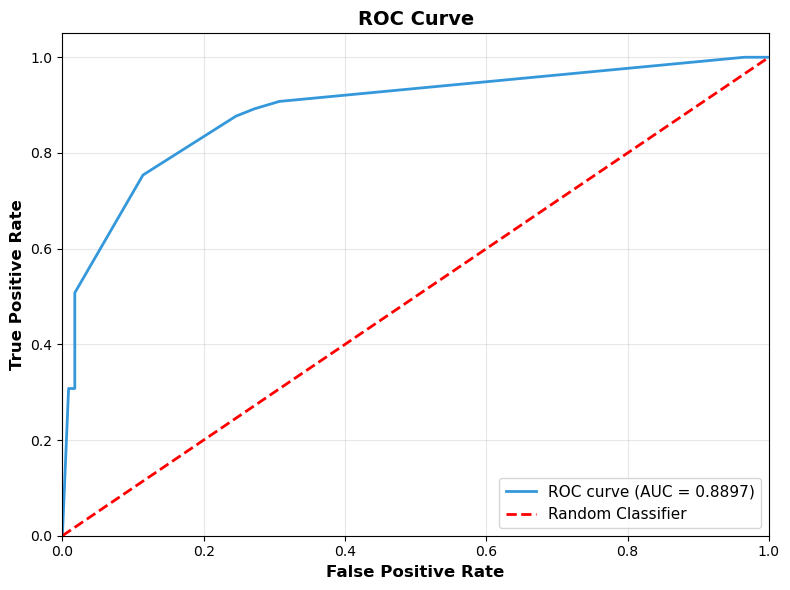

Area Under the Curve (AUC): 0.8897


In [53]:
EvaluationHelper.plot_roc_curve(y_test, probabilities)